In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_fscore_support, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils.class_weight import compute_class_weight
from gensim.models import Word2Vec, FastText

**Dataset**

In [ ]:
# Load IMDb dataset
max_features = 10000
max_len = 300
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Display dataset information
print("Training Data Size:", X_train.shape)
print("Test Data Size:", X_test.shape)

Training Data Size: (25000,)
Test Data Size: (25000,)


In [ ]:
# Display the unique target variables (sentiment labels)
unique_target_values = np.unique(y_train)
print("\nUnique Target Variables:", unique_target_values)


Unique Target Variables: [0 1]


In [ ]:
# Count the number of positive and negative sentiments in the training set
positive_sentiments_train = np.sum(y_train == 1)
negative_sentiments_train = np.sum(y_train == 0)

# Count the number of positive and negative sentiments in the test set
positive_sentiments_test = np.sum(y_test == 1)
negative_sentiments_test = np.sum(y_test == 0)
# Print the number of positive and negative sentiments in the training and test sets
print("\nNumber of Positive Sentiments in Training Set:", positive_sentiments_train)
print("Number of Negative Sentiments in Training Set:", negative_sentiments_train)

print("\nNumber of Positive Sentiments in Test Set:", positive_sentiments_test)
print("Number of Negative Sentiments in Test Set:", negative_sentiments_test)


Number of Positive Sentiments in Training Set: 12500
Number of Negative Sentiments in Training Set: 12500

Number of Positive Sentiments in Test Set: 12500
Number of Negative Sentiments in Test Set: 12500


In [ ]:
# Convert IMDb indices to words for tokenizer use
index_word = imdb.get_word_index()
index_word = {v + 3: k for k, v in index_word.items()}

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Function to decode a review from numeric IDs to words
def decode_review(encoded_review):
    return ' '.join([index_word.get(i - 3, '?') for i in encoded_review])

# Display the first 5 reviews and their corresponding labels
print("First 5 Reviews (decoded):\n")
for i in range(5):
    print(f"Review {i + 1}:")
    print(decode_review(X_train[i]))
    print(f"Label: {'Positive' if y_train[i] == 1 else 'Negative'}")
    print('-' * 80)

First 5 Reviews (decoded):

Review 1:
? in with i like horrible business chinese charm would killer waited which explosion ? going at fun ? film make like lame character has novel ? a all final sense ? real ? find character nothing ? second perhaps they ? find valuable cover this city an br overall ? horror has i ? should shop was in with ? delightful 00 despite ? with their people is i like horrible an well it br garbage ? with this genre this is i taken that ? ? she sex is and house and after ? ? product bud i final which returned be ? does is i an annoying ? film where if at man it's film sent be ? with is comedy you than some ? in perfect i get ? and ? think plot windows it fun ? ? the lou ? sequence at their like horrible wanted on getting night just the ? ? rich br any other ? couple it someone then he decade more on why ? can't ajay that ? family with for still wanted on final ? such his lindsay that if at you interesting how film any ? family would i an g other is i once ? i bo

In [ ]:
# Prepare data as text for training
X_train_text = [" ".join([index_word.get(word, "") for word in review]) for review in X_train]
X_test_text = [" ".join([index_word.get(word, "") for word in review]) for review in X_test]


In [ ]:
# Tokenize text data
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train_text)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=max_len)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=max_len)

In [ ]:
# Function to build and train the model with a given embedding matrix
def build_and_train_model(embedding_matrix):
    model = Sequential()
    model.add(Embedding(input_dim=max_features, output_dim=100, weights=[embedding_matrix],
                        input_length=max_len, trainable=False))
    model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.fit(X_train_seq, y_train, epochs=3, batch_size=32, validation_split=0.2, verbose=1)
    return model

In [ ]:
def evaluate_model(model):
    y_pred = (model.predict(X_test_seq) > 0.5).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    return accuracy, precision, recall, f1

In [ ]:
def get_confusion_matrix(model, X_test_seq, y_test):
    y_pred = (model.predict(X_test_seq) > 0.5).astype(int)
    return confusion_matrix(y_test, y_pred)

**Traditional Embeddings:**

In [ ]:
# 1. Word2Vec Embedding
from gensim.models import Word2Vec

print("Training Word2Vec...")
w2v_model = Word2Vec(X_train_text, vector_size=100, window=5, min_count=1)
embedding_matrix_w2v = np.zeros((max_features, 100))
for word, i in tokenizer.word_index.items():
    if i < max_features and word in w2v_model.wv:
        embedding_matrix_w2v[i] = w2v_model.wv[word]

model_w2v = build_and_train_model(embedding_matrix_w2v)
metrics_w2v = evaluate_model(model_w2v)
print("Word2Vec Metrics:", metrics_w2v)

Training Word2Vec...
Epoch 1/3


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


625/625 ━━━━━━━━━━━━━━━━━━━━ 328s 521ms/step - accuracy: 0.5359 - loss: 0.6729 - val_accuracy: 0.5620 - val_loss: 0.6560
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 336s 448ms/step - accuracy: 0.5543 - loss: 0.6584 - val_accuracy: 0.5472 - val_loss: 0.6675
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 481ms/step - accuracy: 0.5395 - loss: 0.6664 - val_accuracy: 0.5582 - val_loss: 0.6541
782/782 ━━━━━━━━━━━━━━━━━━━━ 122s 155ms/step
Word2Vec Metrics: (0.54732, 0.6093547790719172, 0.26368, 0.36808308671617623)


In [ ]:
glove_path = "/content/glove.6B.100d.txt"  # Update with the correct path

# Load GloVe Embeddings
print("Loading GloVe...")
embedding_index_glove = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index_glove[word] = coefs

# Create Embedding Matrix
embedding_matrix_glove = np.zeros((max_features, 100))
for word, i in tokenizer.word_index.items():
    if i < max_features:
        embedding_vector = embedding_index_glove.get(word)
        if embedding_vector is not None:
            embedding_matrix_glove[i] = embedding_vector

# Build and Train Model with GloVe Embeddings
model_glove = build_and_train_model(embedding_matrix_glove)
accuracy, precision, recall, f1 = evaluate_model(model_glove)

Loading GloVe...


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 276s 438ms/step - accuracy: 0.6214 - loss: 0.6455 - val_accuracy: 0.8094 - val_loss: 0.4301
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 276s 441ms/step - accuracy: 0.7949 - loss: 0.4512 - val_accuracy: 0.8470 - val_loss: 0.3613
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 321s 440ms/step - accuracy: 0.8312 - loss: 0.3845 - val_accuracy: 0.8448 - val_loss: 0.3543
782/782 ━━━━━━━━━━━━━━━━━━━━ 119s 152ms/step


In [ ]:
# 3. FastText Embedding
from gensim.models import FastText

print("Training FastText...")
ft_model = FastText(X_train_text, vector_size=100, window=5, min_count=1, epochs=10)
embedding_matrix_ft = np.zeros((max_features, 100))
for word, i in tokenizer.word_index.items():
    if i < max_features and word in ft_model.wv:
        embedding_matrix_ft[i] = ft_model.wv[word]

model_ft = build_and_train_model(embedding_matrix_ft)
metrics_ft = evaluate_model(model_ft)
print("FastText Metrics:", metrics_ft)



Training FastText...
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 305s 485ms/step - accuracy: 0.5309 - loss: 0.6743 - val_accuracy: 0.5800 - val_loss: 0.6579
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 324s 489ms/step - accuracy: 0.5684 - loss: 0.6587 - val_accuracy: 0.5498 - val_loss: 0.6525
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 485ms/step - accuracy: 0.5505 - loss: 0.6565 - val_accuracy: 0.5782 - val_loss: 0.6482
782/782 ━━━━━━━━━━━━━━━━━━━━ 124s 158ms/step
FastText Metrics: (0.57288, 0.5451571329433925, 0.87984, 0.6731958131847953)


In [ ]:
def display_prediction(sample_index, model_name, y_pred):
    print(f"\n--- {model_name} Prediction ---")
    print(f"Review: {X_test_text[sample_index]}")
    print(f"Actual Sentiment: {'Positive' if y_test[sample_index] == 1 else 'Negative'}")
    print(f"Predicted Sentiment: {'Positive' if y_pred[sample_index] == 1 else 'Negative'}")

In [ ]:
# Summary of Results
print("\nSummary of Metrics:")
print(f"Word2Vec - Accuracy: {metrics_w2v[0]:.4f}, Precision: {metrics_w2v[1]:.4f}, Recall: {metrics_w2v[2]:.4f}, F1: {metrics_w2v[3]:.4f}")
print(f"GloVe - Accuracy={accuracy:.4f}, Precision={precision:.4f}, "f"Recall={recall:.4f}, F1={f1:.4f}")
print(f"FastText - Accuracy: {metrics_ft[0]:.4f}, Precision: {metrics_ft[1]:.4f}, Recall: {metrics_ft[2]:.4f}, F1: {metrics_ft[3]:.4f}")


Summary of Metrics:
Word2Vec - Accuracy: 0.5701, Precision: 0.5455, Recall: 0.8412, F1: 0.6618
GloVe - Accuracy=0.8485, Precision=0.8089, Recall=0.9126, F1=0.8576
FastText - Accuracy: 0.5752, Precision: 0.5471, Recall: 0.8727, F1: 0.6726


In [ ]:
# Compute Confusion Matrices
conf_matrix_w2v = get_confusion_matrix(model_w2v, X_test_seq, y_test)
conf_matrix_glove = get_confusion_matrix(model_glove, X_test_seq, y_test)
conf_matrix_ft = get_confusion_matrix(model_ft, X_test_seq, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 121s 155ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 117s 150ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 120s 154ms/step

Confusion Matrices:
Word2Vec:
 [[10387  2113]
 [ 9204  3296]]
GloVe:
 [[ 9954  2546]
 [ 1163 11337]]
FastText:
 [[ 3324  9176]
 [ 1502 10998]]


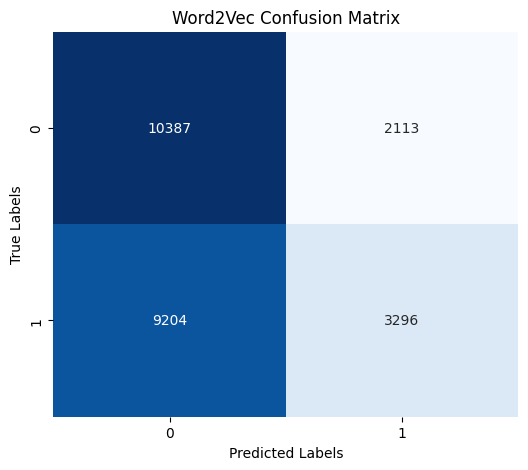

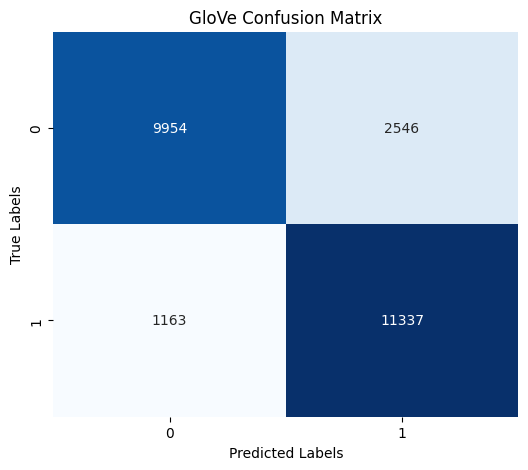

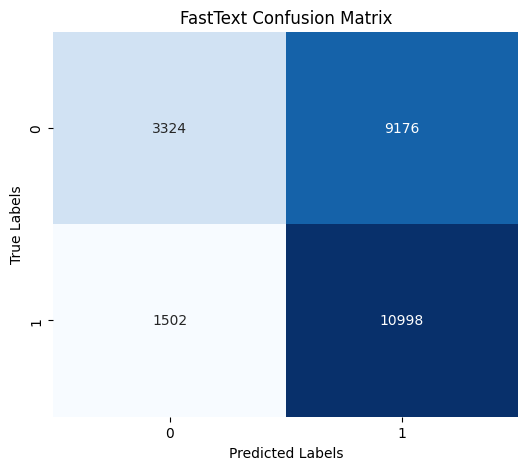

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrix(conf_matrix, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.ylabel('True Labels')
    plt.xlabel('Predicted Labels')
    plt.show()

# Plot confusion matrices for Word2Vec, GloVe, and FastText
plot_confusion_matrix(conf_matrix_w2v, "Word2Vec Confusion Matrix")
plot_confusion_matrix(conf_matrix_glove, "GloVe Confusion Matrix")
plot_confusion_matrix(conf_matrix_ft, "FastText Confusion Matrix")

In [ ]:
y_pred_glove = (model_glove.predict(X_test_seq) > 0.5).astype(int)
y_pred_word2vec = (model_w2v.predict(X_test_seq) > 0.5).astype(int)
y_pred_fasttext = (model_ft.predict(X_test_seq) > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 78s 99ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 70s 89ms/step


In [ ]:
# random_index = random.randint(0, len(X_test) - 1)
random_index = 10000
display_prediction(random_index, "Word2Vec", y_pred_glove)
display_prediction(random_index, "GloVe", y_pred_word2vec)
display_prediction(random_index, "FastText", y_pred_fasttext)


--- Word2Vec Prediction ---
Review:  robert altman nicolas  john luc  you were expecting a fun film the entire family could enjoy these and other directors were obviously chosen because they have not followed the mainstream but created it for those that complain that they did not  to the original story of the opera how often does the music in a film directly relate to what is going on in the film it is the mood that counts this is what i believe the directors of these movies were doing creating a contemporary mood for old operas for the most part they succeed wonderfully with all these operas who is going to like them all we could have used more beverly br br finally what is art even opera without a few naked women
Actual Sentiment: Positive
Predicted Sentiment: Positive

--- GloVe Prediction ---
Review:  robert altman nicolas  john luc  you were expecting a fun film the entire family could enjoy these and other directors were obviously chosen because they have not followed the mainst

**Sentiment Enhanced Word Embeddings**

In [ ]:
# Pad sequences to ensure uniform input size
X_train = pad_sequences(X_train, maxlen=max_len, padding='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post')

In [ ]:
# Define a model with a custom embedding layer to learn sentiment-specific representations
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, trainable=True),
    LSTM(64, return_sequences=True),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary sentiment classification
])

# Compile the model for binary classification
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])



In [ ]:
# Train the model to learn sentiment-enhanced embeddings
history = model.fit(X_train_seq, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 144s 452ms/step - accuracy: 0.5808 - loss: 0.6616 - val_accuracy: 0.8414 - val_loss: 0.3748
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 132s 422ms/step - accuracy: 0.8573 - loss: 0.3472 - val_accuracy: 0.8792 - val_loss: 0.2953
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 469ms/step - accuracy: 0.9260 - loss: 0.2030 - val_accuracy: 0.8796 - val_loss: 0.3093
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 413ms/step - accuracy: 0.9541 - loss: 0.1305 - val_accuracy: 0.8712 - val_loss: 0.3416
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 142s 413ms/step - accuracy: 0.9668 - loss: 0.0989 - val_accuracy: 0.8570 - val_loss: 0.4562
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 129s 412ms/step - accuracy: 0.9802 - loss: 0.0626 - val_accuracy: 0.8670 - val_loss: 0.4925
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 128s 408ms/step - accuracy: 0.9815 - loss: 0.0541 - val_accuracy: 0.8560 - val_loss: 0.5570
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 405ms/step - accuracy: 0.9883 -

In [ ]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

# Calculate additional metrics
y_pred = (model.predict(X_test) > 0.5).astype("int32")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

782/782 - 37s - 48ms/step - accuracy: 0.5116 - loss: 3.4722
Test Loss: 3.4722, Test Accuracy: 0.5116
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step
Accuracy: 0.5116
Precision: 0.5153
Recall: 0.3931
F1 Score: 0.4460


782/782 ━━━━━━━━━━━━━━━━━━━━ 55s 70ms/step


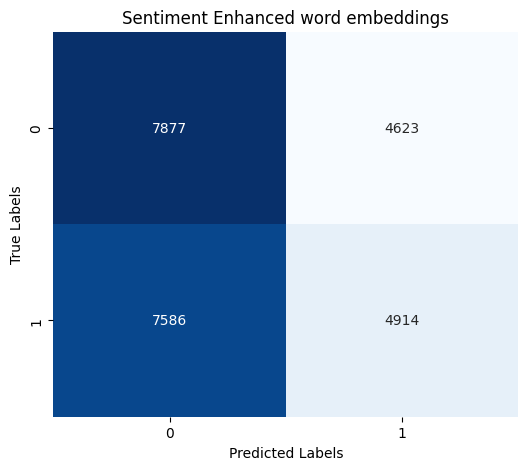

In [ ]:
# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, (model.predict(X_test) > 0.5).astype("int32"))

# Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Sentiment Enhanced word embeddings")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()


In [ ]:
# Save the sentiment-enhanced embedding layer
embedding_layer = model.layers[0]
weights = embedding_layer.get_weights()[0]

**Marathi**

In [ ]:
import pandas as pd

train_df = pd.read_csv('/content/MahaSent_MR_Train.csv')
val_df = pd.read_csv('/content/MahaSent_MR_Val.csv')
test_df = pd.read_csv('/content/MahaSent_MR_Test.csv')


In [ ]:
train_df.head()

,Unnamed: 0,marathi_sentence,label
0,0,माने यांचा घटस्फोट झाला आहे तर मोहितेने नुकतेच...,0
1,1,एका रात्रीत घडणारी किंबहुना बिघडणारी ही गोष्ट आहे,0
2,2,जरी आघात समजण्यायोग्य आहे जरी चित्रपटाला खराब ...,0
3,3,पण तो असा आघातही अनुभवत आहे की तो कोणाशीही शेअ...,0
4,4,छोटे-छोटे गैरसमज मोठ्या अडचणीत येतात,0


In [ ]:
print(train_df.columns)
print(val_df.columns)
print(test_df.columns)

Index(['Unnamed: 0', 'marathi_sentence', 'label'], dtype='object')
Index(['Unnamed: 0', 'marathi_sentence', 'label'], dtype='object')
Index(['Unnamed: 0', 'marathi_sentence', 'label'], dtype='object')


In [ ]:
# Remove all rows with label 0 using .loc[]
train_df = train_df.loc[train_df['label'] != 0]
val_df = val_df.loc[val_df['label'] != 0]
test_df = test_df.loc[test_df['label'] != 0]

# Convert all rows with label -1 to label 0 using .loc[]
train_df.loc[train_df['label'] == -1, 'label'] = 0
val_df.loc[val_df['label'] == -1, 'label'] = 0
test_df.loc[test_df['label'] == -1, 'label'] = 0

In [ ]:
# Show total rows and counts for labels 0 and 1 for each dataset
def label_counts(df):
    total_rows = len(df)
    label_0_count = len(df[df['label'] == 0])
    label_1_count = len(df[df['label'] == 1])
    return total_rows, label_0_count, label_1_count

# Get counts for each dataset
train_total, train_0, train_1 = label_counts(train_df)
val_total, val_0, val_1 = label_counts(val_df)
test_total, test_0, test_1 = label_counts(test_df)

# Print the results
print(f"Train Dataset - Total Rows: {train_total}, Label 0: {train_0}, Label 1: {train_1}")
print(f"Validation Dataset - Total Rows: {val_total}, Label 0: {val_0}, Label 1: {val_1}")
print(f"Test Dataset - Total Rows: {test_total}, Label 0: {test_0}, Label 1: {test_1}")

Train Dataset - Total Rows: 8000, Label 0: 4000, Label 1: 4000
Validation Dataset - Total Rows: 1000, Label 0: 500, Label 1: 500
Test Dataset - Total Rows: 1000, Label 0: 500, Label 1: 500


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# Combine all texts for fitting tokenizer
texts = pd.concat([train_df['marathi_sentence'], val_df['marathi_sentence'], test_df['marathi_sentence']])

# Tokenization and padding
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(train_df['marathi_sentence']), maxlen=300)
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(val_df['marathi_sentence']), maxlen=300)
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(test_df['marathi_sentence']), maxlen=300)

# Labels
y_train = train_df['label']
y_val = val_df['label']
y_test = test_df['label']


In [ ]:
import numpy as np
from gensim.models import Word2Vec

# Train Word2Vec model
w2v_model = Word2Vec(train_texts, vector_size=100, window=5, min_count=1, workers=4)

# Create embedding matrix for Word2Vec
embedding_matrix_w2v = np.zeros((10000, 100))
for word, i in tokenizer.word_index.items():
    if i < 10000 and word in w2v_model.wv.key_to_index:  # Check if word exists in the model's vocabulary
        embedding_matrix_w2v[i] = w2v_model.wv[word]

In [ ]:
from gensim.models import FastText

# Train FastText model
ft_model = FastText(train_texts, vector_size=100, window=5, min_count=1, workers=4)

# Create embedding matrix for FastText
embedding_matrix_ft = np.zeros((10000, 100))
for word, i in tokenizer.word_index.items():
    if i < 10000 and word in ft_model.wv.key_to_index:  # Check if word exists in the model's vocabulary
        embedding_matrix_ft[i] = ft_model.wv[word]


In [ ]:
# Load GloVe embeddings
glove_path = '/content/glove.6B.100d.txt'
embedding_index_glove = {}
with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index_glove[word] = coefs

# Create embedding matrix for GloVe
embedding_matrix_glove = np.zeros((10000, 100))
for word, i in tokenizer.word_index.items():
    if i < 10000:
        embedding_vector = embedding_index_glove.get(word)
        if embedding_vector is not None:
            embedding_matrix_glove[i] = embedding_vector

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout

def build_and_train_model(embedding_matrix):
    model = Sequential()
    model.add(Embedding(input_dim=embedding_matrix.shape[0],
                        output_dim=embedding_matrix.shape[1],
                        weights=[embedding_matrix],
                        input_length=300,
                        trainable=False))
    model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer=Adam(), metrics=['accuracy'])
    model.fit(X_train_seq, y_train, epochs=3, batch_size=32, validation_data=(X_val_seq, y_val))
    return model


In [ ]:
# Train Word2Vec model
model_w2v = build_and_train_model(embedding_matrix_w2v)

# Train FastText model
model_ft = build_and_train_model(embedding_matrix_ft)

# Train GloVe model
model_glove = build_and_train_model(embedding_matrix_glove)


Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 111s 424ms/step - accuracy: 0.5499 - loss: 0.6859 - val_accuracy: 0.5930 - val_loss: 0.6749
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 137s 404ms/step - accuracy: 0.5952 - loss: 0.6709 - val_accuracy: 0.6270 - val_loss: 0.6630
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 102s 407ms/step - accuracy: 0.5997 - loss: 0.6669 - val_accuracy: 0.6020 - val_loss: 0.6617
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 105s 411ms/step - accuracy: 0.5324 - loss: 0.6997 - val_accuracy: 0.5180 - val_loss: 0.6931
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 408ms/step - accuracy: 0.5359 - loss: 0.6884 - val_accuracy: 0.5500 - val_loss: 0.6884
Epoch 3/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 142s 407ms/step - accuracy: 0.5721 - loss: 0.6769 - val_accuracy: 0.5800 - val_loss: 0.6747
Epoch 1/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 107s 414ms/step - accuracy: 0.5085 - loss: 0.6933 - val_accuracy: 0.5040 - val_loss: 0.6935
Epoch 2/3
250/250 ━━━━━━━━━━━━━━━━━━━━ 141s 408ms/step - accuracy: 0.5077 - loss: 0

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
# Function to get predictions and convert probabilities to labels
def get_predictions(model, X_test_seq):
    y_pred = model.predict(X_test_seq)
    return np.argmax(y_pred, axis=-1)

In [ ]:
# Function to calculate precision, recall, and F1 score
def evaluate_model(y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=1)
    return accuracy, precision, recall, f1

In [ ]:
# Function to plot the confusion matrix
def plot_confusion_matrix(y_test, y_pred, title):
    conf_matrix = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

In [ ]:
# Get predictions for each model
y_pred_w2v = get_predictions(model_w2v, X_test_seq)
y_pred_fasttext = get_predictions(model_ft, X_test_seq)
y_pred_glove = get_predictions(model_glove, X_test_seq)

# Evaluate each model
accuracy_w2v, precision_w2v, recall_w2v, f1_w2v = evaluate_model(y_test, y_pred_w2v)
accuracy_fasttext, precision_fasttext, recall_fasttext, f1_fasttext = evaluate_model(y_test, y_pred_fasttext)
accuracy_glove, precision_glove, recall_glove, f1_glove = evaluate_model(y_test, y_pred_glove)

# Print evaluation metrics
print(f"Word2Vec - Accuracy: {accuracy_w2v:.4f}, Precision: {precision_w2v:.4f}, Recall: {recall_w2v:.4f}, F1 Score: {f1_w2v:.4f}")
print(f"FastText - Accuracy: {accuracy_fasttext:.4f}, Precision: {precision_fasttext:.4f}, Recall: {recall_fasttext:.4f}, F1 Score: {f1_fasttext:.4f}")
print(f"GloVe - Accuracy: {accuracy_glove:.4f}, Precision: {precision_glove:.4f}, Recall: {recall_glove:.4f}, F1 Score: {f1_glove:.4f}")


32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 173ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step
Word2Vec - Accuracy: 0.5000, Precision: 0.7500, Recall: 0.5000, F1 Score: 0.3333
FastText - Accuracy: 0.5000, Precision: 0.7500, Recall: 0.5000, F1 Score: 0.3333
GloVe - Accuracy: 0.5000, Precision: 0.7500, Recall: 0.5000, F1 Score: 0.3333


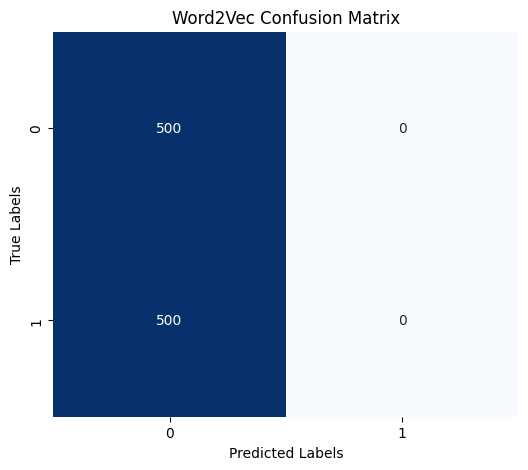

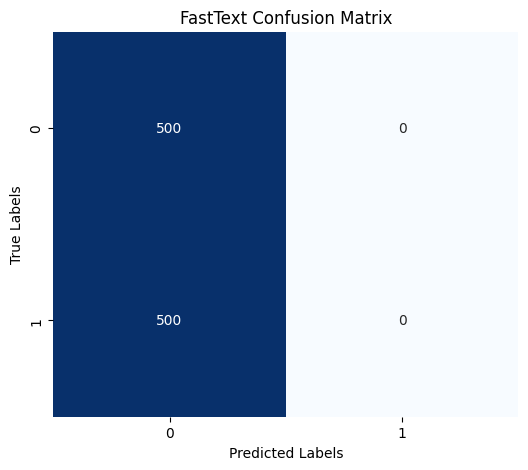

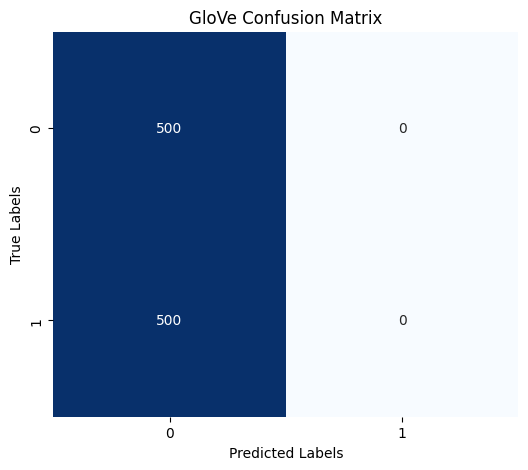

In [ ]:

# Plot confusion matrices for each model
plot_confusion_matrix(y_test, y_pred_w2v, "Word2Vec Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_fasttext, "FastText Confusion Matrix")
plot_confusion_matrix(y_test, y_pred_glove, "GloVe Confusion Matrix")

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.utils import to_categorical

In [ ]:
# Convert labels to categorical
y_train_cat = to_categorical(y_train + 1)  # Shift labels to make them 0, 1, 2
y_val_cat = to_categorical(y_val + 1)
y_test_cat = to_categorical(y_test + 1)

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

In [ ]:
# Define model
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=300),
    SpatialDropout1D(0.2),  # Spatial dropout for regularization
    LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2),  # First LSTM layer
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),  # Second LSTM layer
    Dense(32, activation='relu'),  # Fully connected layer
    Dropout(0.2),  # Dropout for regularization
    Dense(3, activation='softmax')  # Output layer for 3 classes
])

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Train model
history = model.fit(
    X_train_seq, y_train_cat,
    validation_data=(X_val_seq, y_val_cat),
    epochs=10,
    batch_size=32,
    class_weight=class_weights_dict,
    verbose=1)
# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test_seq, y_test_cat, verbose=1)
print(f"Test Accuracy: {test_accuracy:.2f}")


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 177s 690ms/step - accuracy: 0.5371 - loss: 0.7633 - val_accuracy: 0.8070 - val_loss: 0.4556
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 200s 682ms/step - accuracy: 0.8572 - loss: 0.3443 - val_accuracy: 0.8260 - val_loss: 0.4508
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 171s 685ms/step - accuracy: 0.9389 - loss: 0.1827 - val_accuracy: 0.8200 - val_loss: 0.4941
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 202s 684ms/step - accuracy: 0.9660 - loss: 0.1111 - val_accuracy: 0.8250 - val_loss: 0.6157
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 205s 698ms/step - accuracy: 0.9804 - loss: 0.0655 - val_accuracy: 0.8100 - val_loss: 0.7761
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 170s 680ms/step - accuracy: 0.9891 - loss: 0.0391 - val_accuracy: 0.8130 - val_loss: 0.8053
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 204s 689ms/step - accuracy: 0.9888 - loss: 0.0334 - val_accuracy: 0.8130 - val_loss: 1.0331
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 201s 687ms/step - accuracy: 0.9923 -

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step
Accuracy: 0.78
Precision: 0.78
Recall: 0.78
F1 Score: 0.78


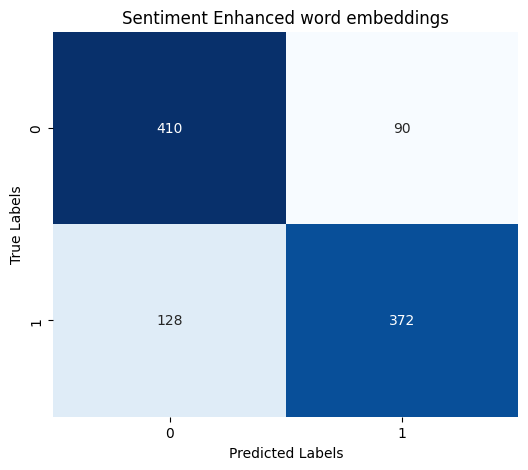

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Function to convert predictions to original label range (-1, 0, 1)
def convert_predictions(y_pred, y_test_cat):
    y_pred_classes = np.argmax(y_pred, axis=1) - 1  # Convert predictions to original labels
    y_true_classes = np.argmax(y_test_cat, axis=1) - 1  # Convert true labels to original labels
    return y_pred_classes, y_true_classes

# Function to evaluate the model
def evaluate_model_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return accuracy, precision, recall, f1

# Function to plot the confusion matrix
def plot_confusion_matrix(y_true, y_pred, title):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

# Predict on the test set
y_test_pred = model.predict(X_test_seq, verbose=1)

# Convert predictions and true labels
y_test_pred_classes, y_test_true_classes = convert_predictions(y_test_pred, y_test_cat)

# Calculate metrics
accuracy, precision, recall, f1 = evaluate_model_metrics(y_test_true_classes, y_test_pred_classes)

# Print metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

# Plot confusion matrix
plot_confusion_matrix(y_test_true_classes, y_test_pred_classes, "Sentiment Enhanced word embeddings")
